# Fine-tuning de ResNet50 para Clasificación de Imágenes

## Introducción

Modelo de clasificación de imágenes utilizando **transfer learning** con ResNet50 preentrenada en ImageNet. La técnica de fine-tuning permite aprovechar las características aprendidas en un dataset masivo (ImageNet) y adaptarlas a nuestro problema específico de clasificación con 4 clases.

### ¿Por qué ResNet50?
- **Arquitectura probada**: ResNet50 es una arquitectura robusta que ha demostrado excelentes resultados
- **Características preentrenadas**: Al estar preentrenada en ImageNet, ya conoce características visuales fundamentales
- **Eficiencia**: Permite obtener buenos resultados con menos datos y tiempo de entrenamiento

## Configuración del Entorno

In [5]:
import torch
import matplotlib.pyplot as plt
from torchvision import models, transforms, datasets
from torch import nn
from torch import optim
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from torchvision.models import resnet50, ResNet50_Weights
from torch.optim.lr_scheduler import StepLR
import seaborn as sns

# Setup
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")  # Use Apple Metal
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU
else:
    device = torch.device("cpu")   # Fallback to CPU
print(f"Using device: {device}")

Using device: mps


## Preprocesamiento de Datos

El preprocesamiento de imágenes es una etapa crucial para asegurar que los datos estén en un formato adecuado para el modelo. A continuación, se definen las transformaciones y se preparan los conjuntos de datos para entrenamiento, validación y prueba.

#### A. Transformaciones de Datos

Las transformaciones se aplican a las imágenes para normalizarlas y prepararlas para la entrada al modelo. Esto incluye:
- Redimensionar las imágenes para estandarizar el tamaño de entrada: se usa 256 porque esto permite hacer un crop central de 224x224 sin perder información importante.
- Recortar el centro de las imágenes: se usa 224 porque ResNet50 fue entrenada con imágenes de 224x224 píxeles.
- Convertir las imágenes a tensores de PyTorch.
- Normalizar los tensores con los valores medios y la desviación estándar precalculados para `ImageNet`.

#### B. Creación de Conjuntos de Datos

Se crean los conjuntos de datos a partir de las imágenes en los directorios especificados, y luego se itera sobre ellos en lotes durante el entrenamiento y la evaluación.

In [6]:
preprocess = transforms.Compose([
    transforms.Resize(256),           # Redimensiona manteniendo proporción
    transforms.CenterCrop(224),       # Recorte central a 224x224
    transforms.ToTensor(),            # Convierte a tensor PyTorch
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])  # Normalización ImageNet
])

In [7]:
dataset = datasets.ImageFolder(root='../data', transform=preprocess)
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])
train_data = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_data = torch.utils.data.DataLoader(test_dataset, batch_size=32)

#### C. Visualización de imágenes

A continuación, se muestra el resultado de una imágen cualquiera después del preprocesamiento de los datos.

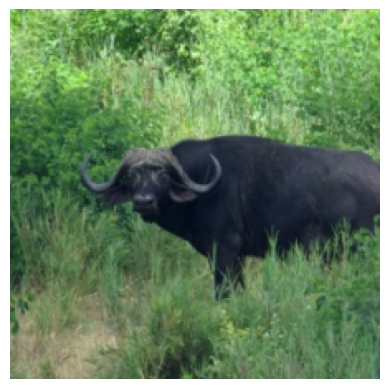

In [8]:
def show_tensor_image(tensor):
    # Si el tensor tiene dimensión 4 (batch), tomamos solo la primera imagen
    if tensor.dim() == 4:
        tensor = tensor[0]

    # Si el tensor es una imagen en formato (Canales, Alto, Ancho)
    if tensor.dim() == 3:
        if tensor.shape[0] == 3:  # Imagen RGB
            tensor = tensor.permute(1, 2, 0)  # Reordenamos a formato (Alto, Ancho, Canales)
        elif tensor.shape[0] == 1:  # Imagen en escala de grises
            tensor = tensor.squeeze(0)  # Quitamos la dimensión del canal

    # Convertir el tensor a numpy y pasarlo a la CPU
    img = tensor.detach().cpu().numpy()

    # Normalizar la imagen si los valores no están en el rango [0,1]
    if img.max() > 1.0 or img.min() < 0.0:
        img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    plt.axis('off')
    plt.show()


for b in test_data:
    data, classes = b
    show_tensor_image(data)
    break

## Definición del Modelo

Se utiliza un modelo pre-entrenado (`ResNet-50`) como base para la clasificación. Este enfoque, conocido como **Transfer Learning**, permite aprovechar el conocimiento adquirido por el modelo en un gran conjunto de datos (`ImageNet`) y aplicarlo a nuestra tarea específica.

#### 1. **Clasificador Personalizado**
- **Linear(2048 → 2048)**: Mantiene dimensionalidad para preservar capacidad representacional
- **ReLU**: Introduce no-linealidad, permitiendo aprender patrones complejos
- **Dropout(0.3)**: Previene sobreajuste eliminando 30% de neuronas aleatoriamente
- **Linear(2048 → num_classes)**: Capa final para clasificación

#### 2. **Estrategia de Congelamiento**
- **Backbone congelado**: Preserva características generales aprendidas en ImageNet
- **Clasificador entrenable**: Se adapta al problema específico
- **Ventajas**: Entrenamiento más rápido, menor riesgo de sobreajuste, requiere menos datos

In [9]:
class FinetuneResnet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        in_feats = self.backbone.fc.in_features  # 2048
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_feats, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(2048, num_classes),
        )
        for p in self.backbone.parameters():
            p.requires_grad = False
        for p in self.backbone.fc.parameters():
            p.requires_grad = True
    def forward(self, x):
        return self.backbone(x)  # retorna logits

## Entrenamiento del Modelo

###  Configuración de Hiperparámetros

En esta sección se definen los criterios y métodos utilizados para optimizar el entrenamiento de la red convolucional:

- **Función de pérdida: `CrossEntropyLoss`**

  - Diseñada para problemas de **clasificación multiclase**.
  - Combina de forma eficiente *softmax* con *negative log likelihood*.
  - Su implementación en PyTorch es **numéricamente estable** y optimizada.

- **Optimizador: `Adam` (lr = 0.0005)**

  - Se usa un *learning rate* de **0.0005**, un valor conservador pero seguro para *fine-tuning*.
  - Adam es un método **adaptativo**, útil en escenarios con gradientes dispersos y que requiere **menos ajuste manual**.

- **Scheduler: `StepLR`**

  - `step_size = 5`: reduce la tasa de aprendizaje cada 5 épocas.
  - `gamma = 0.1`: disminuye el *learning rate* a la décima parte en cada paso.
  - Su propósito es permitir un **refinamiento progresivo del aprendizaje**, comenzando con pasos más grandes y ajustando gradualmente la convergencia.


### Métricas Monitoreadas y Estrategia de Early Stopping

A lo largo del entrenamiento se registran cuatro métricas clave: **pérdida (loss) y exactitud (accuracy) en el conjunto de entrenamiento**, junto con **pérdida y exactitud en el conjunto de prueba**. Estas métricas permiten evaluar tanto el progreso de aprendizaje como la capacidad de generalización del modelo.

Adicionalmente, se emplea una estrategia de **early stopping implícito**: en cada época se guarda el estado del modelo solo si la exactitud en el conjunto de prueba supera el mejor valor obtenido previamente. Al final del proceso, se carga este estado óptimo, garantizando que el modelo final corresponda al mejor desempeño observado y no necesariamente a la última época entrenada.

De esta forma, se logra prevenir el sobreajuste y asegurar que el modelo resultante sea más robusto y generalizable.



In [10]:
# Inicializar modelo
model = FinetuneResnet(4)
model = model.to(device)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lr=0.0005, params=model.parameters())

# Programador de tasa de aprendizaje
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs=10):
    """
    Entrenar el modelo y registrar métricas
    """
    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []

    best_test_acc = 0.0
    best_model_state = None

    for epoch in range(num_epochs):
        # Fase de entrenamiento
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total_train += target.size(0)
            correct_train += (predicted == target).sum().item()

            if batch_idx % 10 == 0:
                print(f'Época {epoch + 1}/{num_epochs}, Lote {batch_idx}/{len(train_loader)}, Pérdida: {loss.item():.4f}')

        # Calcular métricas de entrenamiento
        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct_train / total_train
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Fase de evaluación
        test_loss, test_acc = evaluate_model(model, test_loader, criterion)
        test_losses.append(test_loss)
        test_accuracies.append(test_acc)

        # Guardar el mejor modelo
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_model_state = model.state_dict().copy()

        # Actualizar la tasa de aprendizaje
        scheduler.step()

        print(f'Época {epoch + 1}/{num_epochs}:')
        print(f'Pérdida Entrenamiento: {train_loss:.4f}, Exactitud Entrenamiento: {train_acc:.2f}%')
        print(f'Pérdida Prueba: {test_loss:.4f}, Exactitud Prueba: {test_acc:.2f}%')
        print(f'Tasa de Aprendizaje: {optimizer.param_groups[0]["lr"]:.6f}')
        print('-' * 60)

    # Cargar el mejor modelo
    model.load_state_dict(best_model_state)
    print(f'Mejor Exactitud en Prueba: {best_test_acc:.2f}%')

    return train_losses, train_accuracies, test_losses, test_accuracies


## Evaluación y Métricas

Una vez finalizado el entrenamiento, es fundamental evaluar el modelo para comprender su desempeño real y validar su capacidad de generalización. Para ello se incluyen varias funciones que permiten analizar los resultados desde diferentes perspectivas:

- **Evaluación general (`evaluate_model`)**
  Calcula métricas globales como *pérdida promedio en el conjunto de prueba* y *exactitud (accuracy)*. Estas medidas proporcionan una visión rápida de la calidad del modelo.

- **Evaluación detallada (`detailed_evaluation`)**
  Genera un *classification report* con métricas por clase (precisión, recall y F1-score), junto con una *matriz de confusión*. Esto permite identificar clases en las que el modelo funciona bien y aquellas donde tiene mayor dificultad.

- **Historial de entrenamiento (`plot_training_history`)**
  Visualiza la evolución de la pérdida y la exactitud durante las épocas de entrenamiento y validación. Estas gráficas son útiles para detectar sobreajuste o subentrenamiento.

- **Predicción individual (`predict_single_image`)**
  Permite probar el modelo en imágenes específicas. Además de mostrar la clase predicha y su nivel de confianza, grafica la probabilidad asignada a cada clase, lo que aporta transparencia al proceso de decisión.

Finalmente, los resultados obtenidos se complementan con la **visualización de métricas y gráficos**, y se guarda el modelo entrenado en disco (`best_resnet_model.pth`) para su reutilización sin necesidad de reentrenar.


Iniciando entrenamiento...
Época 1/10, Lote 0/100, Pérdida: 1.3970
Época 1/10, Lote 10/100, Pérdida: 0.5178
Época 1/10, Lote 20/100, Pérdida: 0.2332
Época 1/10, Lote 30/100, Pérdida: 0.1662
Época 1/10, Lote 40/100, Pérdida: 0.1601
Época 1/10, Lote 50/100, Pérdida: 0.0331
Época 1/10, Lote 60/100, Pérdida: 0.2439
Época 1/10, Lote 70/100, Pérdida: 0.2199
Época 1/10, Lote 80/100, Pérdida: 0.1844
Época 1/10, Lote 90/100, Pérdida: 0.0982
Época 1/10:
Pérdida Entrenamiento: 0.2299, Exactitud Entrenamiento: 92.06%
Pérdida Prueba: 0.0463, Exactitud Prueba: 98.50%
Tasa de Aprendizaje: 0.000500
------------------------------------------------------------
Época 2/10, Lote 0/100, Pérdida: 0.0461
Época 2/10, Lote 10/100, Pérdida: 0.0887
Época 2/10, Lote 20/100, Pérdida: 0.0513
Época 2/10, Lote 30/100, Pérdida: 0.1512
Época 2/10, Lote 40/100, Pérdida: 0.1089
Época 2/10, Lote 50/100, Pérdida: 0.0835
Época 2/10, Lote 60/100, Pérdida: 0.0071
Época 2/10, Lote 70/100, Pérdida: 0.0219
Época 2/10, Lote 80/10

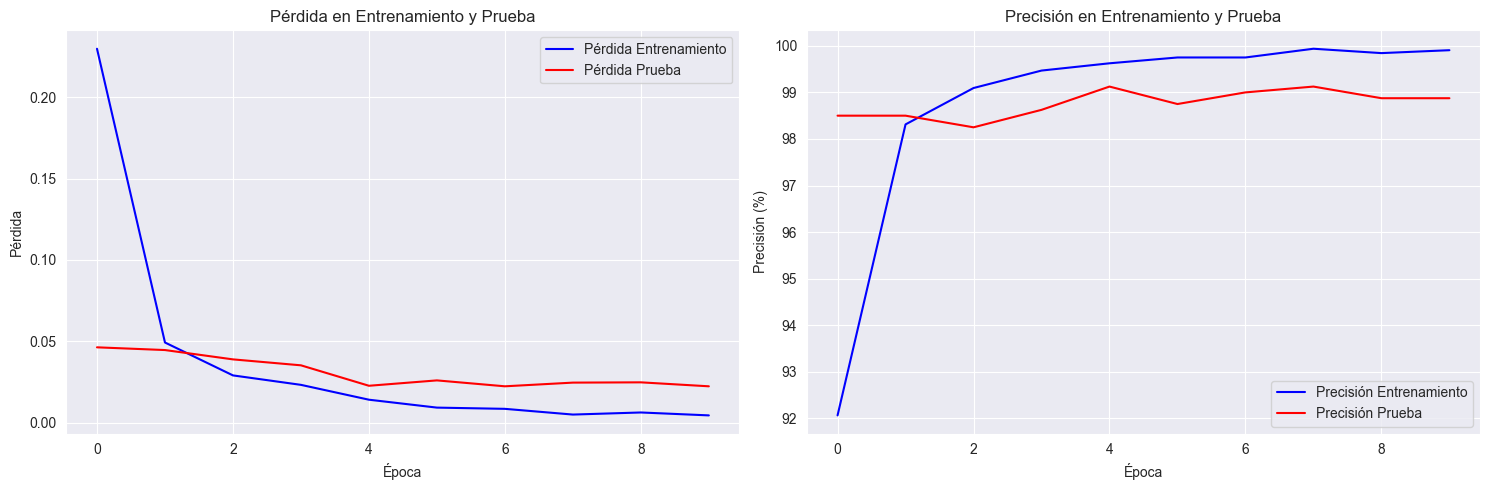


Evaluación Detallada:
Reporte de Clasificación:
              precision    recall  f1-score   support

     Buffalo       0.99      0.98      0.98       208
    Elephant       0.99      1.00      0.99       202
       Rhino       0.97      0.99      0.98       185
       Zebra       1.00      1.00      1.00       205

    accuracy                           0.99       800
   macro avg       0.99      0.99      0.99       800
weighted avg       0.99      0.99      0.99       800



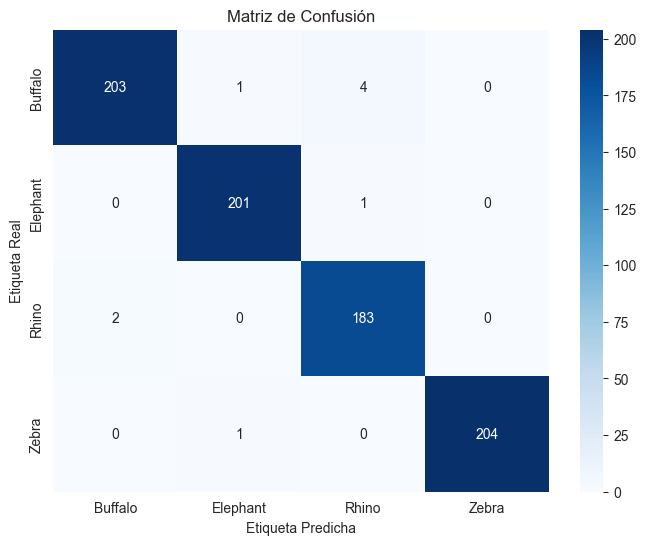

Modelo guardado como 'best_resnet_model.pth'


In [11]:
def evaluate_model(model, test_loader, criterion):
    """
    Evalúa el modelo con datos de prueba
    """
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    test_loss /= len(test_loader)
    accuracy = 100. * correct / total

    return test_loss, accuracy


def detailed_evaluation(model, test_loader, class_names):
    """
    Evaluación detallada con reporte de clasificación y matriz de confusión
    """
    model.eval()
    all_predictions = []
    all_targets = []
    all_probabilities = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            probabilities = nn.functional.softmax(output, dim=1)
            _, predicted = torch.max(output, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    # Reporte de clasificación
    print("Reporte de Clasificación:")
    print(classification_report(all_targets, all_predictions, target_names=class_names))

    # Matriz de confusión
    cm = confusion_matrix(all_targets, all_predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Matriz de Confusión')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Etiqueta Predicha')
    plt.show()

    return all_predictions, all_targets, all_probabilities


def plot_training_history(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Grafica el historial de entrenamiento (pérdida y precisión)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Gráfica de pérdidas
    ax1.plot(train_losses, label='Pérdida Entrenamiento', color='blue')
    ax1.plot(test_losses, label='Pérdida Prueba', color='red')
    ax1.set_title('Pérdida en Entrenamiento y Prueba')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Pérdida')
    ax1.legend()
    ax1.grid(True)

    # Gráfica de precisiones
    ax2.plot(train_accuracies, label='Precisión Entrenamiento', color='blue')
    ax2.plot(test_accuracies, label='Precisión Prueba', color='red')
    ax2.set_title('Precisión en Entrenamiento y Prueba')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Precisión (%)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


def predict_single_image(model, image_path, class_names, transform):
    """
    Predice la clase para una sola imagen
    """
    from PIL import Image

    # Cargar y preprocesar la imagen
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Hacer predicción
    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = nn.functional.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = class_names[predicted.item()]
    confidence_score = confidence.item()

    # Mostrar imagen y predicción
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title(f'Predicción: {predicted_class} (Confianza: {confidence_score:.2f})')
    plt.axis('off')
    plt.show()

    # Mostrar todas las probabilidades de clase
    probs = probabilities.cpu().numpy()[0]
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_names, probs)
    plt.title('Probabilidades por Clase')
    plt.ylabel('Probabilidad')
    plt.xticks(rotation=45)

    # Resaltar clase predicha
    max_idx = np.argmax(probs)
    bars[max_idx].set_color('red')

    for i, v in enumerate(probs):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center')

    plt.tight_layout()
    plt.show()

    return predicted_class, confidence_score


# Entrenar el modelo
print("Iniciando entrenamiento...")
train_losses, train_accs, test_losses, test_accs = train_model(
    model, train_data, test_data, criterion, optimizer, scheduler, num_epochs=10
)

# Graficar historial de entrenamiento
plot_training_history(train_losses, train_accs, test_losses, test_accs)

# Evaluación detallada
print("\nEvaluación Detallada:")
predictions, targets, probabilities = detailed_evaluation(model, test_data, dataset.classes)

# Guardar el modelo entrenado
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'class_names': dataset.classes,
    'best_test_accuracy': max(test_accs)
}, 'best_resnet_model.pth')

print("Modelo guardado como 'best_resnet_model.pth'")


In [12]:
# Métricas de evaluación adicionales
def calculate_per_class_accuracy(predictions, targets, class_names):
    """
    Calcular la exactitud (accuracy) para cada clase
    """
    per_class_acc = {}  # Diccionario para guardar la exactitud por clase
    for i, class_name in enumerate(class_names):
        class_mask = (np.array(targets) == i)  # Se seleccionan las instancias de la clase actual
        if class_mask.sum() > 0:
            class_predictions = np.array(predictions)[class_mask]  # Predicciones de esa clase
            class_targets = np.array(targets)[class_mask]  # Valores reales de esa clase
            accuracy = (class_predictions == class_targets).mean() * 100  # Exactitud en porcentaje
            per_class_acc[class_name] = accuracy
        else:
            per_class_acc[class_name] = 0.0  # Si no hay muestras de esa clase, se asigna 0

    # Mostrar los resultados
    print("\nExactitud por clase:")
    for class_name, acc in per_class_acc.items():
        print(f"{class_name}: {acc:.2f}%")

    return per_class_acc

# Calcular y mostrar la exactitud por clase
per_class_acc = calculate_per_class_accuracy(predictions, targets, dataset.classes)


Exactitud por clase:
Buffalo: 97.60%
Elephant: 99.50%
Rhino: 98.92%
Zebra: 99.51%


### Cargar un modelo previamente entrenado para inferencia

Este proceso es fundamental cuando queremos reutilizar un modelo ya entrenado para realizar predicciones, sin necesidad de volver a entrenarlo desde cero.


In [13]:
def load_trained_model(model_path, num_classes):
    """
    Cargar un modelo entrenado desde un checkpoint
    """
    model = FinetuneResnet(num_classes)  # Se define el modelo con la misma arquitectura usada en entrenamiento
    checkpoint = torch.load(model_path, map_location=device)  # Se carga el checkpoint guardado
    model.load_state_dict(checkpoint['model_state_dict'])  # Se restauran los pesos del modelo
    model.to(device)  # Se envía el modelo al dispositivo (CPU o GPU)

    return model, checkpoint['class_names']

# Ejemplo de uso:
# loaded_model, class_names = load_trained_model('best_resnet_model.pth', 4)

# Ejemplo: Predecir sobre una sola imagen
# (Descomentar y modificar la ruta para probar con una imagen específica)
# predicted_class, confidence = predict_single_image(
#     model,
#     'ruta/a/tu/imagen.jpg',
#     dataset.classes,
#     preproce

### Resultados Obtenidos

Los resultados del modelo evidencian un desempeño sólido y bien balanceado:

- **Pérdida (Loss):**
  La pérdida en entrenamiento disminuyó de manera rápida y constante, alcanzando valores cercanos a cero. En el conjunto de prueba, aunque se observaron fluctuaciones, la pérdida se mantuvo en un rango bajo, lo que indica una buena capacidad de generalización.

- **Precisión (Accuracy):**
  Tanto en entrenamiento como en prueba se alcanzaron valores cercanos al **99 %**. En el conjunto de prueba se presentaron ligeras variaciones, posiblemente asociadas a episodios menores de sobreajuste, pero sin afectar de forma significativa el rendimiento global.

- **Matriz de confusión:**
  El modelo logró clasificar correctamente la gran mayoría de instancias. Los errores se presentaron de forma aislada y sin concentrarse en clases específicas, lo que confirma la robustez del clasificador.

- **Precisión por clase:**
  El análisis detallado mostró un desempeño balanceado en todas las categorías, alcanzando altos niveles de precisión sin evidenciar sesgos hacia clases particulares.

En conjunto, estos resultados reflejan que el modelo no solo aprendió adecuadamente las características de los datos, sino que también generaliza de manera efectiva, alcanzando un rendimiento competitivo y estable en todas las métricas evaluadas.

